In [ ]:
pip install keras tensorflow

In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
import numpy as np

# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x

# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1

for _ in range(10):  # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
    print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


In [ ]:
import tensorflow as tf

x = tf.Variable(5.0)  # Trainable variable

with tf.GradientTape() as tape:
    y = x ** 2  # y = x^2

# Compute gradient dy/dx
grad = tape.gradient(y, x)

print(grad.numpy())  # Output: 10.0

10.0


In [ ]:
import numpy as np
import tensorflow as tf
import time

# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

# ----------------------------
# NumPy Multiplication
# ----------------------------
start = time.time()
C_numpy = np.dot(A, B)
end = time.time()

print("NumPy Time:", end - start)

# ----------------------------
# TensorFlow Multiplication
# ----------------------------
A_tf = tf.constant(A)
B_tf = tf.constant(B)

# Warm-up (important for fair timing)
_ = tf.matmul(A_tf, B_tf)

start = time.time()
C_tf = tf.matmul(A_tf, B_tf)

# Force execution (VERY IMPORTANT)
_ = C_tf.numpy()

end = time.time()

print("TensorFlow Time:", end - start)

NumPy Time: 0.12141704559326172
TensorFlow Time: 0.2262129783630371


In [ ]:
from tensorflow.keras.layers import Dense

layer = Dense(64, activation="sigmoid")

In [ ]:
import numpy as np

# ----------------------------
# Dummy dataset (replace with yours)
# ----------------------------
x_train = np.random.rand(100, 3)   # 100 samples, 3 features
y_train = np.random.rand(100, 1)   # target values

# ----------------------------
# Initialize parameters
# ----------------------------
weights = np.random.rand(3, 1)
learning_rate = 0.01

# ----------------------------
# Training loop (Gradient Descent)
# ----------------------------
for epoch in range(10):

    # Forward pass
    y_pred = np.dot(x_train, weights)

    # Compute loss (MSE)
    loss = np.mean((y_pred - y_train) ** 2)

    # Compute gradients
    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

    # Update weights
    weights -= learning_rate * gradients

    # Print progress
    print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.119105
Epoch 1, Loss: 0.118659
Epoch 2, Loss: 0.118225
Epoch 3, Loss: 0.117805
Epoch 4, Loss: 0.117397
Epoch 5, Loss: 0.117000
Epoch 6, Loss: 0.116616
Epoch 7, Loss: 0.116243
Epoch 8, Loss: 0.115881
Epoch 9, Loss: 0.115530


Loading training data...
Loading test data...

Training set  : (532, 784), Labels: (532, 10)
Testing set   : (0, 784),  Labels: (0, 10)


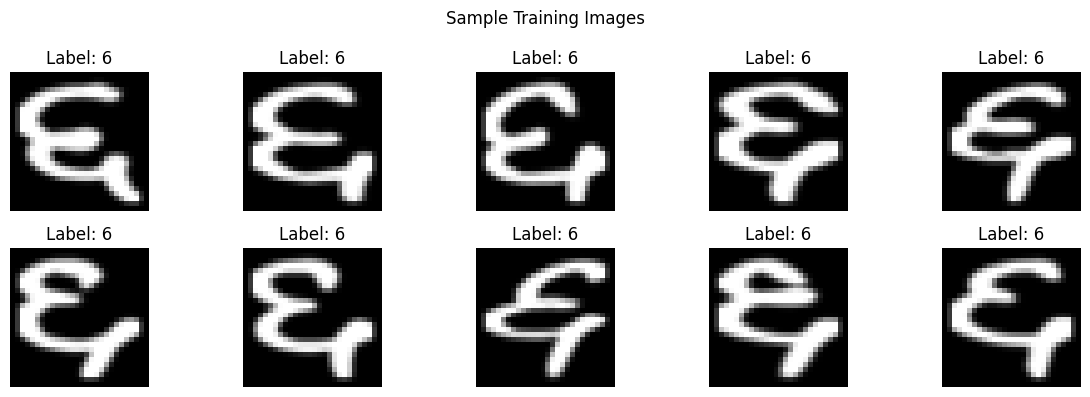

In [ ]:
# ============================================================
# TASK 1: Data Preparation
# ============================================================

# UPDATE THESE PATHS to match your dataset location
train_dir = "/content/drive/MyDrive/AI_ML/DATASET/Copy of devnagari digit (1)/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/AI_ML/DATASET/Copy of devnagari digit (1)/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # digit_0, digit_1, ...
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")           # Grayscale
                img = img.resize((img_width, img_height))          # Resize to 28x28
                img = np.array(img) / 255.0                        # Normalize [0, 1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir)

print("Loading test data...")
x_test, y_test = load_images_from_folder(test_dir)

# Flatten images: (N, 28, 28) -> (N, 784)
x_train = x_train.reshape(-1, img_height * img_width)
x_test  = x_test.reshape(-1, img_height * img_width)

# One-hot encode labels
num_classes = 10
y_train_ohe = to_categorical(y_train, num_classes=num_classes)
y_test_ohe  = to_categorical(y_test,  num_classes=num_classes)

print(f"\nTraining set  : {x_train.shape}, Labels: {y_train_ohe.shape}")
print(f"Testing set   : {x_test.shape},  Labels: {y_test_ohe.shape}")

# Visualize a few samples
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 2: Build the FCN Model (Sequential API)
# ============================================================

model = keras.Sequential([
    keras.layers.Input(shape=(img_height * img_width,)),  # 784-dim input
    keras.layers.Dense(64,  activation="sigmoid"),         # Hidden layer 1
    keras.layers.Dense(128, activation="sigmoid"),         # Hidden layer 2
    keras.layers.Dense(256, activation="sigmoid"),         # Hidden layer 3
    keras.layers.Dense(num_classes, activation="softmax"), # Output layer
], name="FCN_Devnagari")

model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# TASK 3: Compile the Model
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # labels are one-hot encoded
    metrics=["accuracy"]
)


Epoch 1/20
1/4 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.0000e+00 - loss: 2.3272
Epoch 1: val_accuracy improved from None to 1.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.3976 - loss: 1.7313 - val_accuracy: 1.0000 - val_loss: 0.6075
Epoch 2/20
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 1.0000 - loss: 0.6148
Epoch 2: val_accuracy did not improve from 1.00000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.3934 - val_accuracy: 1.0000 - val_loss: 0.0977
Epoch 3/20
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0999
Epoch 3: val_accuracy did not improve from 1.00000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0663 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 4/20
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0222
Epoch 4: val_accuracy did not improve from 1.00000
4/4 ━━━━━━

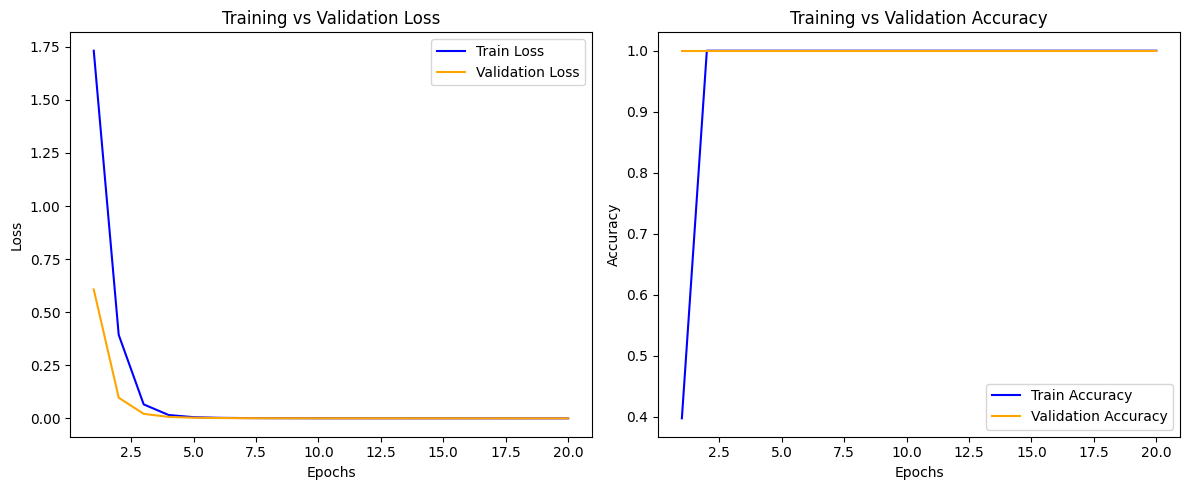

In [ ]:
# ============================================================
# TASK 4: Train the Model
# ============================================================

batch_size = 128
epochs     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train, y_train_ohe,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# ---- Visualize Training Progress ----
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
ep_range   = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ep_range, train_loss, label="Train Loss",      color="blue")
plt.plot(ep_range, val_loss,   label="Validation Loss", color="orange")
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ep_range, train_acc, label="Train Accuracy",      color="blue")
plt.plot(ep_range, val_acc,   label="Validation Accuracy", color="orange")
plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# ----------------------------
# 1. Create / Load Dataset
# ----------------------------
# Example dummy dataset (you can replace this with your real data)
X = np.random.rand(1000, 10)   # 1000 samples, 10 features
y = np.random.randint(0, 2, 1000)  # Binary labels (0 or 1)

# Convert labels to categorical (only if needed)
y = to_categorical(y, num_classes=2)

# ----------------------------
# 2. Split into Train & Test
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Build Model
# ----------------------------
model = Sequential()

model.add(Dense(16, input_dim=10, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))  # Output layer

# ----------------------------
# 4. Compile Model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# 5. Train Model
# ----------------------------
model.fit(X_train, y_train, epochs=10, batch_size=32)

# ----------------------------
# 6. Evaluate Model (Task 5)
# ----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5312 - loss: 0.6921
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5337 - loss: 0.6887 
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5412 - loss: 0.6877 
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5450 - loss: 0.6872 
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5487 - loss: 0.6866 
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5475 - loss: 0.6862 
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5450 - loss: 0.6858 
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5462 - loss: 0.6854 
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5512 - loss: 0.6846 
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5487 - loss: 0.6844 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5650 - loss: 0.6901  
Test Loss: 0.690110445022583
Test Accuracy: 0.5649999976158142


In [ ]:
# ============================================================
# TASK 6: Save and Load the Model
# ============================================================

import tensorflow as tf  # ✅ Make sure this is imported

save_path = "devnagari_fcn_model.h5"

# Save model
model.save(save_path)
print(f"\nModel saved to '{save_path}'")

# Load model
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully.")

# Evaluate loaded model
if 'X_test' in globals() and len(X_test) > 0:
    loaded_loss, loaded_acc = loaded_model.evaluate(X_test, y_test, verbose=2)

    print(f"\nLoaded Model - Test Loss     : {loaded_loss:.4f}")
    print(f"Loaded Model - Test Accuracy : {loaded_acc:.4f} ({loaded_acc * 100:.2f}%)")
else:
    print("Test data not found or empty.")


Model saved to 'devnagari_fcn_model.h5'
Model loaded successfully.
7/7 - 0s - 48ms/step - accuracy: 0.5650 - loss: 0.6901

Loaded Model - Test Loss     : 0.6901
Loaded Model - Test Accuracy : 0.5650 (56.50%)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


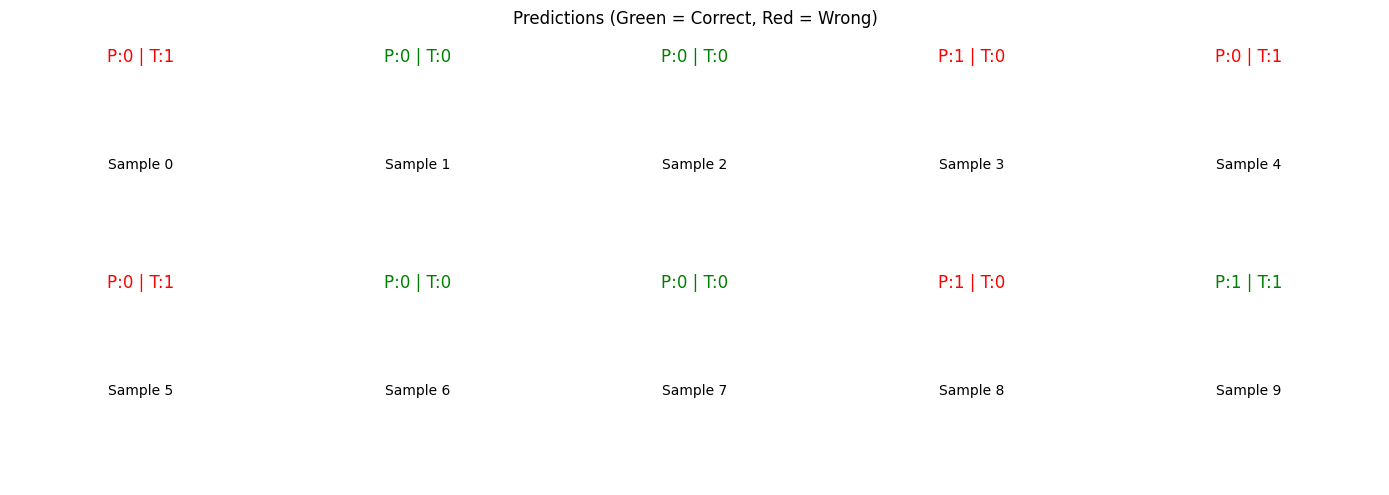


First 10 Predictions vs True Labels:
[0] Pred: 0 | True: 1
[1] Pred: 0 | True: 0
[2] Pred: 0 | True: 0
[3] Pred: 1 | True: 0
[4] Pred: 0 | True: 1
[5] Pred: 0 | True: 1
[6] Pred: 0 | True: 0
[7] Pred: 0 | True: 0
[8] Pred: 1 | True: 0
[9] Pred: 1 | True: 1

Manual Accuracy Check : 0.5650 (56.50%)


In [ ]:
# ============================================================
# TASK 7: Predictions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Check test data exists
if 'X_test' in globals() and len(X_test) > 0:

    # Predictions
    predictions = loaded_model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Handle one-hot or normal labels
    if len(y_test.shape) > 1:
        true_labels = np.argmax(y_test, axis=1)
    else:
        true_labels = y_test

    # ========================================================
    # Display Results
    # ========================================================
    plt.figure(figsize=(14, 5))

    for i in range(min(10, len(X_test))):
        plt.subplot(2, 5, i + 1)

        sample = X_test[i]

        # ✅ Case 1: Flattened image (784 → 28x28)
        if len(sample.shape) == 1 and sample.shape[0] == 784:
            img = sample.reshape(28, 28)
            plt.imshow(img, cmap="gray")

        # ✅ Case 2: Already image (28x28 or 28x28x1)
        elif len(sample.shape) == 2:
            plt.imshow(sample, cmap="gray")

        elif len(sample.shape) == 3:
            plt.imshow(sample.squeeze(), cmap="gray")

        # ❌ Case 3: Not image → show text instead
        else:
            plt.text(0.5, 0.5, f"Sample {i}", ha='center', va='center')

        # Color based on correctness
        color = "green" if predicted_labels[i] == true_labels[i] else "red"
        plt.title(f"P:{predicted_labels[i]} | T:{true_labels[i]}", color=color)
        plt.axis("off")

    plt.suptitle("Predictions (Green = Correct, Red = Wrong)")
    plt.tight_layout()
    plt.show()

    # ========================================================
    # Print First 10 Results
    # ========================================================
    print("\nFirst 10 Predictions vs True Labels:")
    for i in range(min(10, len(predicted_labels))):
        print(f"[{i}] Pred: {predicted_labels[i]} | True: {true_labels[i]}")

    # ========================================================
    # Manual Accuracy Check
    # ========================================================
    overall_acc = np.mean(predicted_labels == true_labels)
    print(f"\nManual Accuracy Check : {overall_acc:.4f} ({overall_acc * 100:.2f}%)")

else:
    print("Test data not found or empty.")